In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [2]:
df = pd.read_csv("train.csv")

# Fix date columns immediately
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print("Shape:", df.shape)
df.head()

Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# For RFM we only need these 4 columns
rfm_cols = ["Customer ID", "Customer Name", "Order Date", "Sales"]
print(df[rfm_cols].head(10))

  Customer ID    Customer Name Order Date     Sales
0    CG-12520      Claire Gute 2017-11-08  261.9600
1    CG-12520      Claire Gute 2017-11-08  731.9400
2    DV-13045  Darrin Van Huff 2017-06-12   14.6200
3    SO-20335   Sean O'Donnell 2016-10-11  957.5775
4    SO-20335   Sean O'Donnell 2016-10-11   22.3680
5    BH-11710  Brosina Hoffman 2015-06-09   48.8600
6    BH-11710  Brosina Hoffman 2015-06-09    7.2800
7    BH-11710  Brosina Hoffman 2015-06-09  907.1520
8    BH-11710  Brosina Hoffman 2015-06-09   18.5040
9    BH-11710  Brosina Hoffman 2015-06-09  114.9000


In [4]:
print("Total customers:", df["Customer ID"].nunique())
print("Total orders:", df["Order ID"].nunique())
print("Date range:", df["Order Date"].min().date(), "→", df["Order Date"].max().date())

Total customers: 793
Total orders: 4922
Date range: 2015-01-03 → 2018-12-30


In [5]:
# We use the day after the last order as our reference point
reference_date = df["Order Date"].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date.date())

Reference date: 2018-12-31


CALCULATE RFM VALUE PER CUSTOMER

In [6]:
rfm = df.groupby(["Customer ID", "Customer Name"]).agg(
    Recency  = ("Order Date", lambda x: (reference_date - x.max()).days),
    Frequency= ("Order ID",   "nunique"),
    Monetary = ("Sales",      "sum")
).reset_index()

rfm["Monetary"] = rfm["Monetary"].round(2)
rfm.head(10)

,Customer ID,Customer Name,Recency,Frequency,Monetary
0,AA-10315,Alex Avila,185,5,5563.56
1,AA-10375,Allen Armold,20,9,1056.39
2,AA-10480,Andrew Allen,260,4,1790.51
3,AA-10645,Anna Andreadi,56,6,5086.93
4,AB-10015,Aaron Bergman,416,3,886.16
5,AB-10060,Adam Bellavance,55,8,7755.62
6,AB-10105,Adrian Barton,42,10,14473.57
7,AB-10150,Aimee Bixby,42,5,966.71
8,AB-10165,Alan Barnes,26,8,1113.84
9,AB-10255,Alejandro Ballentine,167,9,914.53


In [7]:
# Quick statistics

print("── RFM STATISTICS ──────────────────────")
print(f"Avg Recency  : {rfm['Recency'].mean():.0f} days")
print(f"Avg Frequency: {rfm['Frequency'].mean():.1f} orders")
print(f"Avg Monetary : ${rfm['Monetary'].mean():,.2f}")
print(f"\nTop spender  : ${rfm['Monetary'].max():,.2f}")
print(f"Most frequent: {rfm['Frequency'].max()} orders")
print(f"Most recent  : {rfm['Recency'].min()} days ago")

── RFM STATISTICS ──────────────────────
Avg Recency  : 149 days
Avg Frequency: 6.2 orders
Avg Monetary : $2,851.87

Top spender  : $25,043.05
Most frequent: 17 orders
Most recent  : 1 days ago


In [8]:
# Sort by highest spenders
rfm.sort_values("Monetary", ascending=False).head(10)

,Customer ID,Customer Name,Recency,Frequency,Monetary
700,SM-20320,Sean Miller,80,5,25043.05
741,TC-20980,Tamara Chand,400,5,19052.22
621,RB-19360,Raymond Buch,97,6,15117.34
730,TA-21385,Tom Ashbrook,70,4,14595.62
6,AB-10105,Adrian Barton,42,10,14473.57
434,KL-16645,Ken Lonsdale,48,12,14175.23
669,SC-20095,Sanjit Chand,350,9,14142.33
327,HL-15040,Hunter Lopez,44,6,12873.30
683,SE-20110,Sanjit Engle,10,11,12209.44
131,CC-12370,Christopher Conant,44,5,12129.07


In [9]:
# Score Recency (reversed — lower days = better = higher score)
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=4, 
                          labels=[4, 3, 2, 1]).astype(int)

# Score Frequency
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=4,
                          labels=[1, 2, 3, 4]).astype(int)

# Score Monetary
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=4,
                          labels=[1, 2, 3, 4]).astype(int)

rfm[["Customer Name", "Recency", "Frequency", "Monetary",
     "R_Score", "F_Score", "M_Score"]].head(10)

,Customer Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,Alex Avila,185,5,5563.56,2,2,4
1,Allen Armold,20,9,1056.39,4,4,1
2,Andrew Allen,260,4,1790.51,1,1,2
3,Anna Andreadi,56,6,5086.93,3,2,4
4,Aaron Bergman,416,3,886.16,1,1,1
5,Adam Bellavance,55,8,7755.62,3,3,4
6,Adrian Barton,42,10,14473.57,3,4,4
7,Aimee Bixby,42,5,966.71,3,2,1
8,Alan Barnes,26,8,1113.84,4,3,2
9,Alejandro Ballentine,167,9,914.53,2,4,1


In [10]:
# Combine all 3 scores into one total score
rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

print("Minimum RFM Score:", rfm["RFM_Score"].min())
print("Maximum RFM Score:", rfm["RFM_Score"].max())
print("Average RFM Score:", rfm["RFM_Score"].mean().round(2))

Minimum RFM Score: 3
Maximum RFM Score: 12
Average RFM Score: 7.5


In [11]:
sean = rfm[rfm["Customer Name"] == "Sean Miller"]
print(sean[["Customer Name", "Recency", "Frequency", 
            "Monetary", "R_Score", "F_Score", "M_Score", "RFM_Score"]])

    Customer Name  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
700   Sean Miller       80          5  25043.05        2        2        4   

     RFM_Score  
700          8  


In [20]:
def segment_customer(score):
    if score >= 10:
        return "Champions"
    elif score >= 8:
        return "Loyal Customers"
    elif score >= 6:
        return "Potential Loyalists"
    elif score >= 4:
        return "At Risk"
    else:
        return "Lost Customers"

rfm["Segment"] = rfm["RFM_Score"].apply(segment_customer)
print("✅ Segments updated")
rfm.head(10)

✅ Segments updated


,Customer ID,Customer Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,AA-10315,Alex Avila,185,5,5563.56,2,2,4,8,Loyal Customers
1,AA-10375,Allen Armold,20,9,1056.39,4,4,1,9,Loyal Customers
2,AA-10480,Andrew Allen,260,4,1790.51,1,1,2,4,At Risk
3,AA-10645,Anna Andreadi,56,6,5086.93,3,2,4,9,Loyal Customers
4,AB-10015,Aaron Bergman,416,3,886.16,1,1,1,3,Lost Customers
5,AB-10060,Adam Bellavance,55,8,7755.62,3,3,4,10,Champions
6,AB-10105,Adrian Barton,42,10,14473.57,3,4,4,11,Champions
7,AB-10150,Aimee Bixby,42,5,966.71,3,2,1,6,Potential Loyalists
8,AB-10165,Alan Barnes,26,8,1113.84,4,3,2,9,Loyal Customers
9,AB-10255,Alejandro Ballentine,167,9,914.53,2,4,1,7,Potential Loyalists


In [21]:
segment_counts = rfm["Segment"].value_counts()
print( "CUSTOMER SEGMENTS ")
for segment, count in segment_counts.items():
    pct = (count / len(rfm)) * 100
    print(f"{segment:<25} {count:>4} customers ({pct:.1f}%)")
print("─" * 45)
print(f"Total customers: {len(rfm)}")

CUSTOMER SEGMENTS 
Loyal Customers            212 customers (26.7%)
Champions                  201 customers (25.3%)
Potential Loyalists        183 customers (23.1%)
At Risk                    140 customers (17.7%)
Lost Customers              57 customers (7.2%)
─────────────────────────────────────────────
Total customers: 793


In [22]:
# average RFM values persegment

segment_summary = rfm.groupby("Segment").agg(
    Customers = ("Customer ID",  "count"),
    Avg_Recency   = ("Recency",   "mean"),
    Avg_Frequency = ("Frequency", "mean"),
    Avg_Monetary  = ("Monetary",  "mean")
).round(2)

segment_summary = segment_summary.sort_values("Avg_Monetary", ascending=False)
print(segment_summary)

                     Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Segment                                                                 
Champions                  201        37.31           8.79       4699.89
Loyal Customers            212        94.43           6.89       3640.69
Potential Loyalists        183       148.48           5.31       1973.22
At Risk                    140       255.77           4.04       1118.60
Lost Customers              57       489.19           2.77        479.47


In [23]:
# checking for sean miller segment

print(rfm[rfm["Customer Name"] == "Sean Miller"]
      [["Customer Name", "RFM_Score", "Segment"]])

    Customer Name  RFM_Score          Segment
700   Sean Miller          8  Loyal Customers


VISUALIZATION


In [25]:
fig_colors = {
    "Champions"          : "#06d6a0",
    "Loyal Customers"    : "#4cc9f0",
    "Potential Loyalists": "#ffd166",
    "At Risk"            : "#f4a261",
    "Lost Customers"     : "#e63946"
}

segment_order = ["Champions", "Loyal Customers", 
                 "Potential Loyalists", "At Risk", 
                 "Lost Customers"]

segment_counts = rfm["Segment"].value_counts()
print("✅ Colors ready")

✅ Colors ready


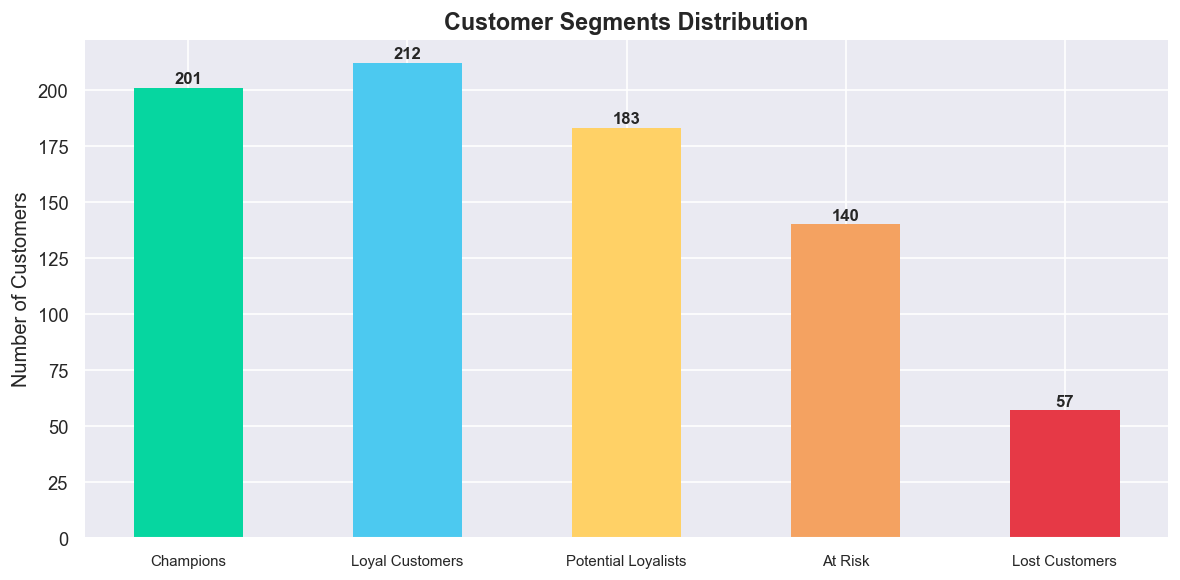

In [28]:
plt.figure(figsize=(10, 5))
segment_order = ["Champions", "Loyal Customers", 
                 "Potential Loyalists", "At Risk", 
                 "Lost Customers"]

counts = [segment_counts.get(s, 0) for s in segment_order]
colors = [fig_colors[s] for s in segment_order]

bars = plt.bar(segment_order, counts, color=colors, edgecolor="none", width=0.5)

# Add value labels on top of bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(count), ha="center", fontsize=10, fontweight="bold")

plt.title("Customer Segments Distribution", fontsize=14, fontweight="bold")
plt.ylabel("Number of Customers")
plt.xticks(fontsize=9)
plt.tight_layout()
plt.show()

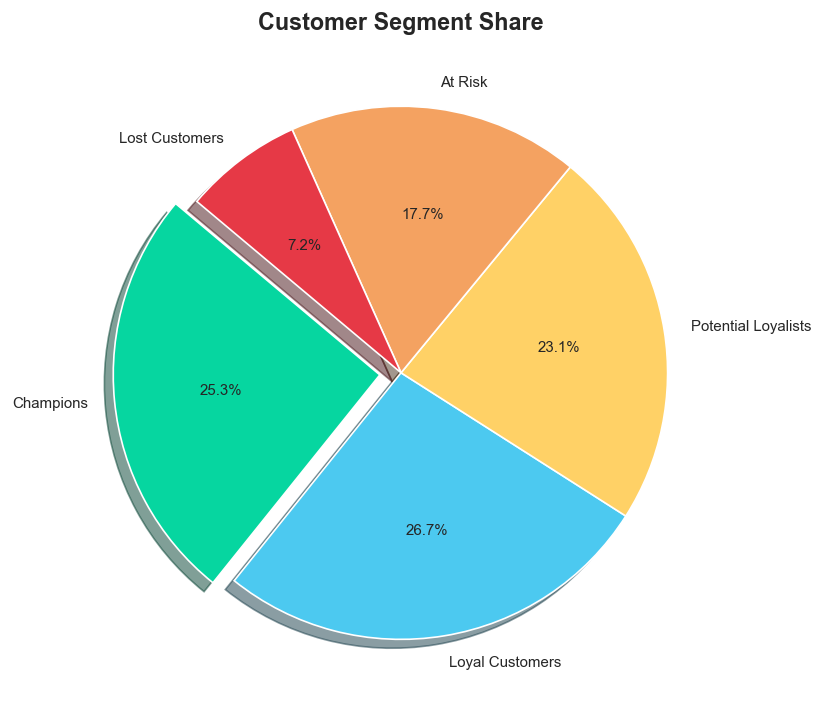

In [29]:
plt.figure(figsize=(7, 7))
counts_pie = [segment_counts.get(s, 0) for s in segment_order]
explode    = (0.08, 0, 0, 0, 0)

plt.pie(counts_pie, labels=segment_order,
        autopct="%1.1f%%", startangle=140,
        explode=explode, shadow=True,
        colors=colors,
        textprops={"fontsize": 9})

plt.title("Customer Segment Share", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

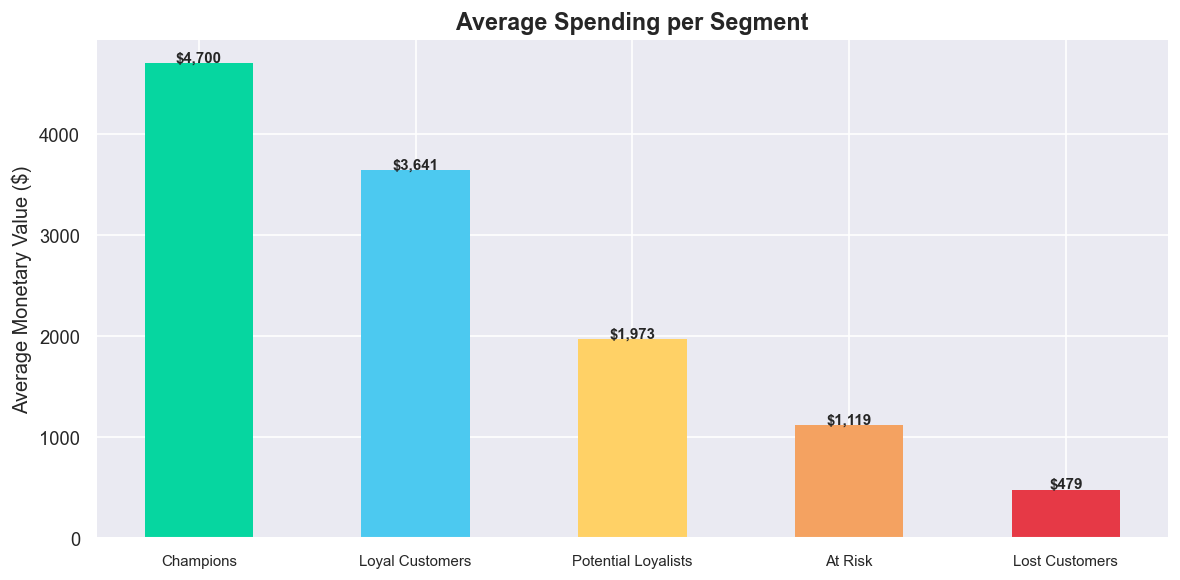

In [31]:
# average monetary value per segment

plt.figure(figsize=(10, 5))
monetary_vals = [segment_summary.loc[s, "Avg_Monetary"] 
                 if s in segment_summary.index else 0 
                 for s in segment_order]

bars = plt.bar(segment_order, monetary_vals, color=colors, 
               edgecolor="none", width=0.5)

for bar, val in zip(bars, monetary_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f"${val:,.0f}", ha="center", fontsize=9, fontweight="bold")

plt.title("Average Spending per Segment", fontsize=14, fontweight="bold")
plt.ylabel("Average Monetary Value ($)")
plt.xticks(fontsize=9)
plt.tight_layout()
plt.show()

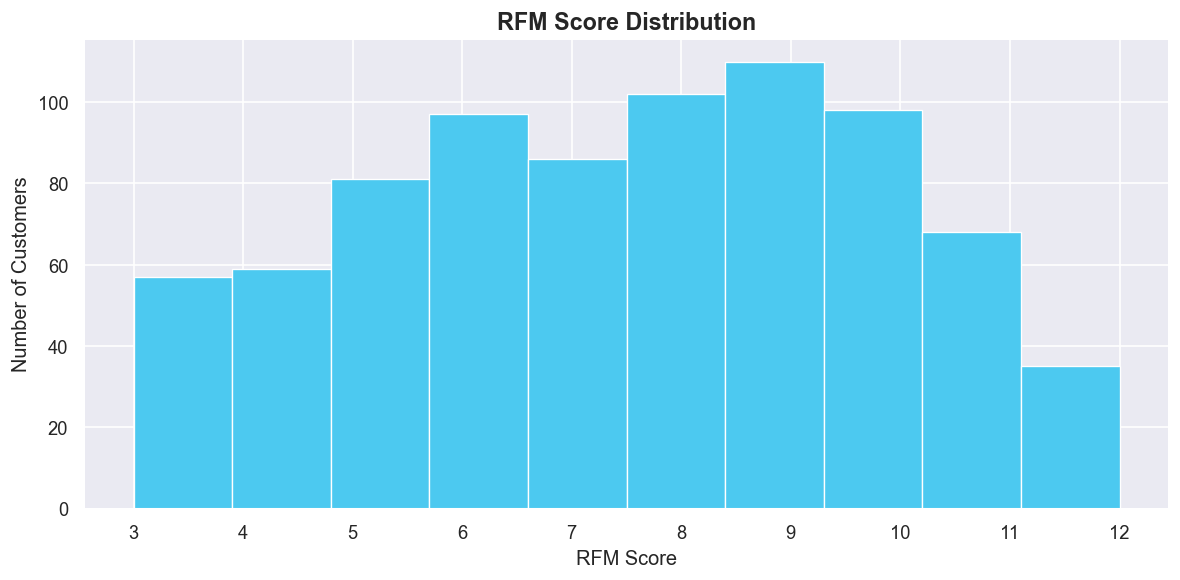

In [32]:
# RFM score distribution

plt.figure(figsize=(10, 5))
plt.hist(rfm["RFM_Score"], bins=10, color="#4cc9f0", 
         edgecolor="white", linewidth=0.8)
plt.title("RFM Score Distribution", fontsize=14, fontweight="bold")
plt.xlabel("RFM Score")
plt.ylabel("Number of Customers")
plt.xticks(range(3, 13))
plt.tight_layout()
plt.show()

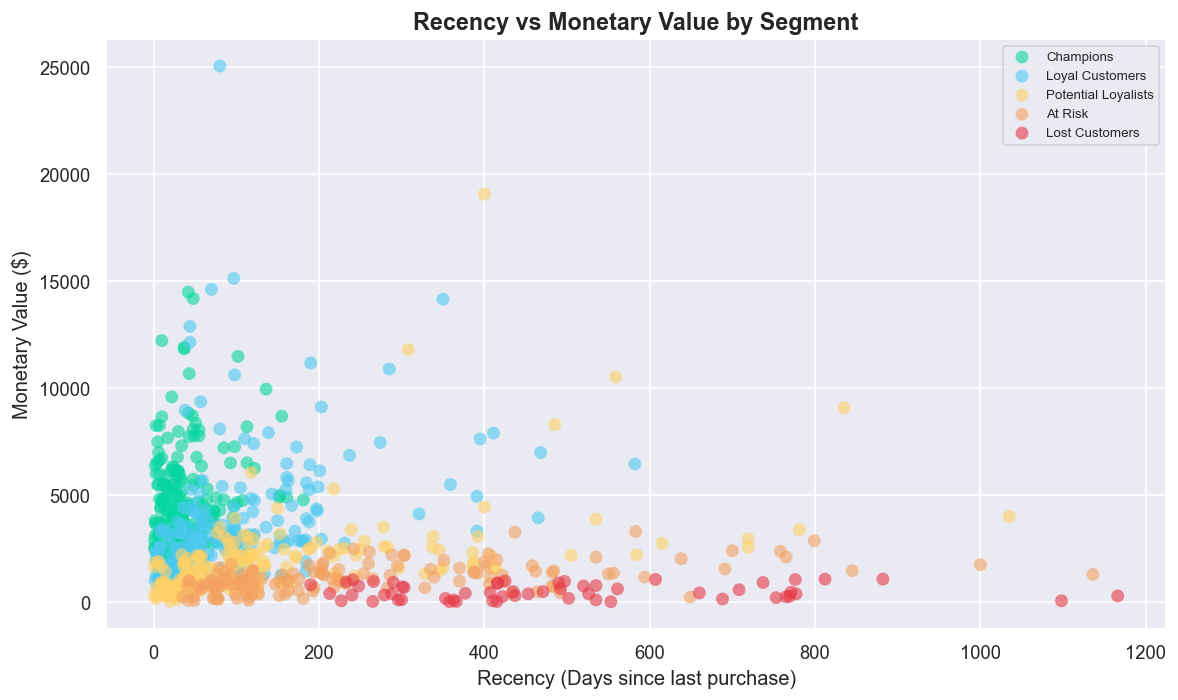

In [33]:
plt.figure(figsize=(10, 6))

for segment in segment_order:
    subset = rfm[rfm["Segment"] == segment]
    plt.scatter(subset["Recency"], subset["Monetary"],
                label=segment, color=fig_colors[segment],
                alpha=0.6, edgecolors="none", s=60)

plt.title("Recency vs Monetary Value by Segment", 
          fontsize=14, fontweight="bold")
plt.xlabel("Recency (Days since last purchase)")
plt.ylabel("Monetary Value ($)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

BUSINESS INSIGHTSAND RECOMMENDATIONS

In [34]:
# Revenue contribution per segment

revenue_by_segment = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

total_revenue = revenue_by_segment.sum()
print("REVENUE CONTRIBUTION BY SEGMENT")
for segment, revenue in revenue_by_segment.items():
    pct = (revenue / total_revenue) * 100
    print(f"{segment:<22} ${revenue:>10,.2f}  ({pct:.1f}%)")
print("─" * 50)
print(f"{'Total':<22} ${total_revenue:>10,.2f}")

REVENUE CONTRIBUTION BY SEGMENT
Champions              $944,677.67  (41.8%)
Loyal Customers        $771,826.30  (34.1%)
Potential Loyalists    $361,098.71  (16.0%)
At Risk                $156,604.25  (6.9%)
Lost Customers         $ 27,329.88  (1.2%)
──────────────────────────────────────────────────
Total                  $2,261,536.81


In [41]:
# top 10 champions

top_champions = rfm[rfm["Segment"] == "Champions"]\
                .sort_values("Monetary", ascending=False)\
                .head(10)[["Customer Name", "Recency", 
                            "Frequency", "Monetary", "RFM_Score"]]

print("         TOP 10 CHAMPION CUSTOMERS")
print(top_champions.to_string(index=False))

         TOP 10 CHAMPION CUSTOMERS
   Customer Name  Recency  Frequency  Monetary  RFM_Score
   Adrian Barton       42         10  14473.57         11
    Ken Lonsdale       48         12  14175.23         11
    Sanjit Engle       10         11  12209.44         12
    Todd Sumrall       37          6  11891.75         10
       Greg Tran       37         11  11820.12         11
     Seth Vernon      102         10  11470.95         10
   Maria Etezadi       43         10  10663.73         11
    Edward Hooks      136         10   9940.38         10
        John Lee       22         10   9576.34         12
Justin Deggeller       42          8   8828.03         11


In [40]:
# at risk customers who spend the most

at_risk = rfm[rfm["Segment"] == "At Risk"]\
          .sort_values("Monetary", ascending=False)\
          .head(10)[["Customer Name", "Recency", 
                     "Frequency", "Monetary", "RFM_Score"]]

print("     TOP 10 AT RISK CUSTOMERS (High Spenders)")
print(at_risk.to_string(index=False))

     TOP 10 AT RISK CUSTOMERS (High Spenders)
  Customer Name  Recency  Frequency  Monetary  RFM_Score
  Brian Stugart      583          3   3288.11          5
Lindsay Castell      437          4   3246.63          5
  Craig Carroll      799          4   2854.12          5
    Darren Budd      242          4   2469.67          5
 David Flashing      700          3   2390.53          5
     Jack Garza      758          3   2358.68          5
   Craig Leslie      261          4   2335.59          5
    Fred Harton      213          4   2271.28          5
   Justin Hirsh      405          4   2256.39          5
  Edward Nazzal      288          4   2199.37          4


In [39]:
# lost customers

lost = rfm[rfm["Segment"] == "Lost Customers"]\
       .sort_values("Monetary", ascending=False)\
       .head(10)[["Customer Name", "Recency", 
                  "Frequency", "Monetary", "RFM_Score"]]

print("           TOP 10 LOST CUSTOMERS")
print(lost.to_string(index=False))

           TOP 10 LOST CUSTOMERS
    Customer Name  Recency  Frequency  Monetary  RFM_Score
    Pauline Chand      882          2   1061.49          3
   David Philippe      812          2   1058.62          3
    Duane Huffman      776          4   1043.10          3
Susan MacKendrick      607          1   1043.04          3
     Mike Kennedy      241          4   1031.60          3
 Cindy Schnelling      425          4    970.11          3
     Rachel Payne      497          4    954.65          3
    Bryan Spruell      266          2    949.43          3
    Alyssa Crouse      233          3    925.80          3
         Ken Dana      290          4    907.16          3


FINAL INSIGHT AND SUMMARY


In [42]:
champions    = rfm[rfm["Segment"] == "Champions"]
loyal        = rfm[rfm["Segment"] == "Loyal Customers"]
at_risk      = rfm[rfm["Segment"] == "At Risk"]
lost         = rfm[rfm["Segment"] == "Lost Customers"]
potential    = rfm[rfm["Segment"] == "Potential Loyalists"]

print("=" * 55)
print("     CUSTOMER SEGMENTATION INSIGHTS SUMMARY")
print("=" * 55)
print(f"""
📊 OVERVIEW
   Total Customers     : {len(rfm)}
   Total Revenue       : ${rfm["Monetary"].sum():,.2f}
   Avg Customer Value  : ${rfm["Monetary"].mean():,.2f}
   Avg Recency         : {rfm["Recency"].mean():.0f} days

🏆 CHAMPIONS ({len(champions)} customers — {len(champions)/len(rfm)*100:.1f}%)
   Avg Spend    : ${champions["Monetary"].mean():,.2f}
   Avg Frequency: {champions["Frequency"].mean():.1f} orders
   Avg Recency  : {champions["Recency"].mean():.0f} days
   → These are your VIP customers. Reward them with
     loyalty programs and early access to new products.

⭐ LOYAL CUSTOMERS ({len(loyal)} customers — {len(loyal)/len(rfm)*100:.1f}%)
   Avg Spend    : ${loyal["Monetary"].mean():,.2f}
   Avg Frequency: {loyal["Frequency"].mean():.1f} orders
   → Nurture these customers. They are one step away
     from becoming Champions with the right incentives.

🔼 POTENTIAL LOYALISTS ({len(potential)} customers — {len(potential)/len(rfm)*100:.1f}%)
   Avg Spend    : ${potential["Monetary"].mean():,.2f}
   Avg Frequency: {potential["Frequency"].mean():.1f} orders
   → Engage them with personalized offers and product
     recommendations to increase purchase frequency.

⚠️  AT RISK ({len(at_risk)} customers — {len(at_risk)/len(rfm)*100:.1f}%)
   Avg Spend    : ${at_risk["Monetary"].mean():,.2f}
   Avg Recency  : {at_risk["Recency"].mean():.0f} days
   → Launch win-back campaigns immediately. Send
     personalized discounts to re-engage them before
     they become lost customers.

❌ LOST CUSTOMERS ({len(lost)} customers — {len(lost)/len(rfm)*100:.1f}%)
   Avg Spend    : ${lost["Monetary"].mean():,.2f}
   Avg Recency  : {lost["Recency"].mean():.0f} days
   → Last chance re-engagement campaigns. Offer
     significant discounts to bring them back.
""")
print("=" * 55)
print("  BUSINESS RECOMMENDATIONS")
print("=" * 55)
print("""
  1. Protect Champions — launch a VIP loyalty program
     to retain your top 25% of customers

  2. Upgrade Loyal Customers — targeted upsell campaigns
     to move them into the Champions segment

  3. Win back At Risk customers — automated email
     campaigns with personalized discount codes

  4. Re-engage Lost Customers — last chance offers
     with significant discounts before writing them off

  5. Nurture Potential Loyalists — product recommendations
     and bundle offers to increase order frequency
""")
print("=" * 55)

     CUSTOMER SEGMENTATION INSIGHTS SUMMARY

📊 OVERVIEW
   Total Customers     : 793
   Total Revenue       : $2,261,536.81
   Avg Customer Value  : $2,851.87
   Avg Recency         : 149 days

🏆 CHAMPIONS (201 customers — 25.3%)
   Avg Spend    : $4,699.89
   Avg Frequency: 8.8 orders
   Avg Recency  : 37 days
   → These are your VIP customers. Reward them with
     loyalty programs and early access to new products.

⭐ LOYAL CUSTOMERS (212 customers — 26.7%)
   Avg Spend    : $3,640.69
   Avg Frequency: 6.9 orders
   → Nurture these customers. They are one step away
     from becoming Champions with the right incentives.

🔼 POTENTIAL LOYALISTS (183 customers — 23.1%)
   Avg Spend    : $1,973.22
   Avg Frequency: 5.3 orders
   → Engage them with personalized offers and product
     recommendations to increase purchase frequency.

⚠️  AT RISK (140 customers — 17.7%)
   Avg Spend    : $1,118.60
   Avg Recency  : 256 days
   → Launch win-back campaigns immediately. Send
     personalized 

In [43]:
rfm.to_csv("customer_segments.csv", index=False)
print("✅ Customer segments saved as customer_segments.csv")

✅ Customer segments saved as customer_segments.csv


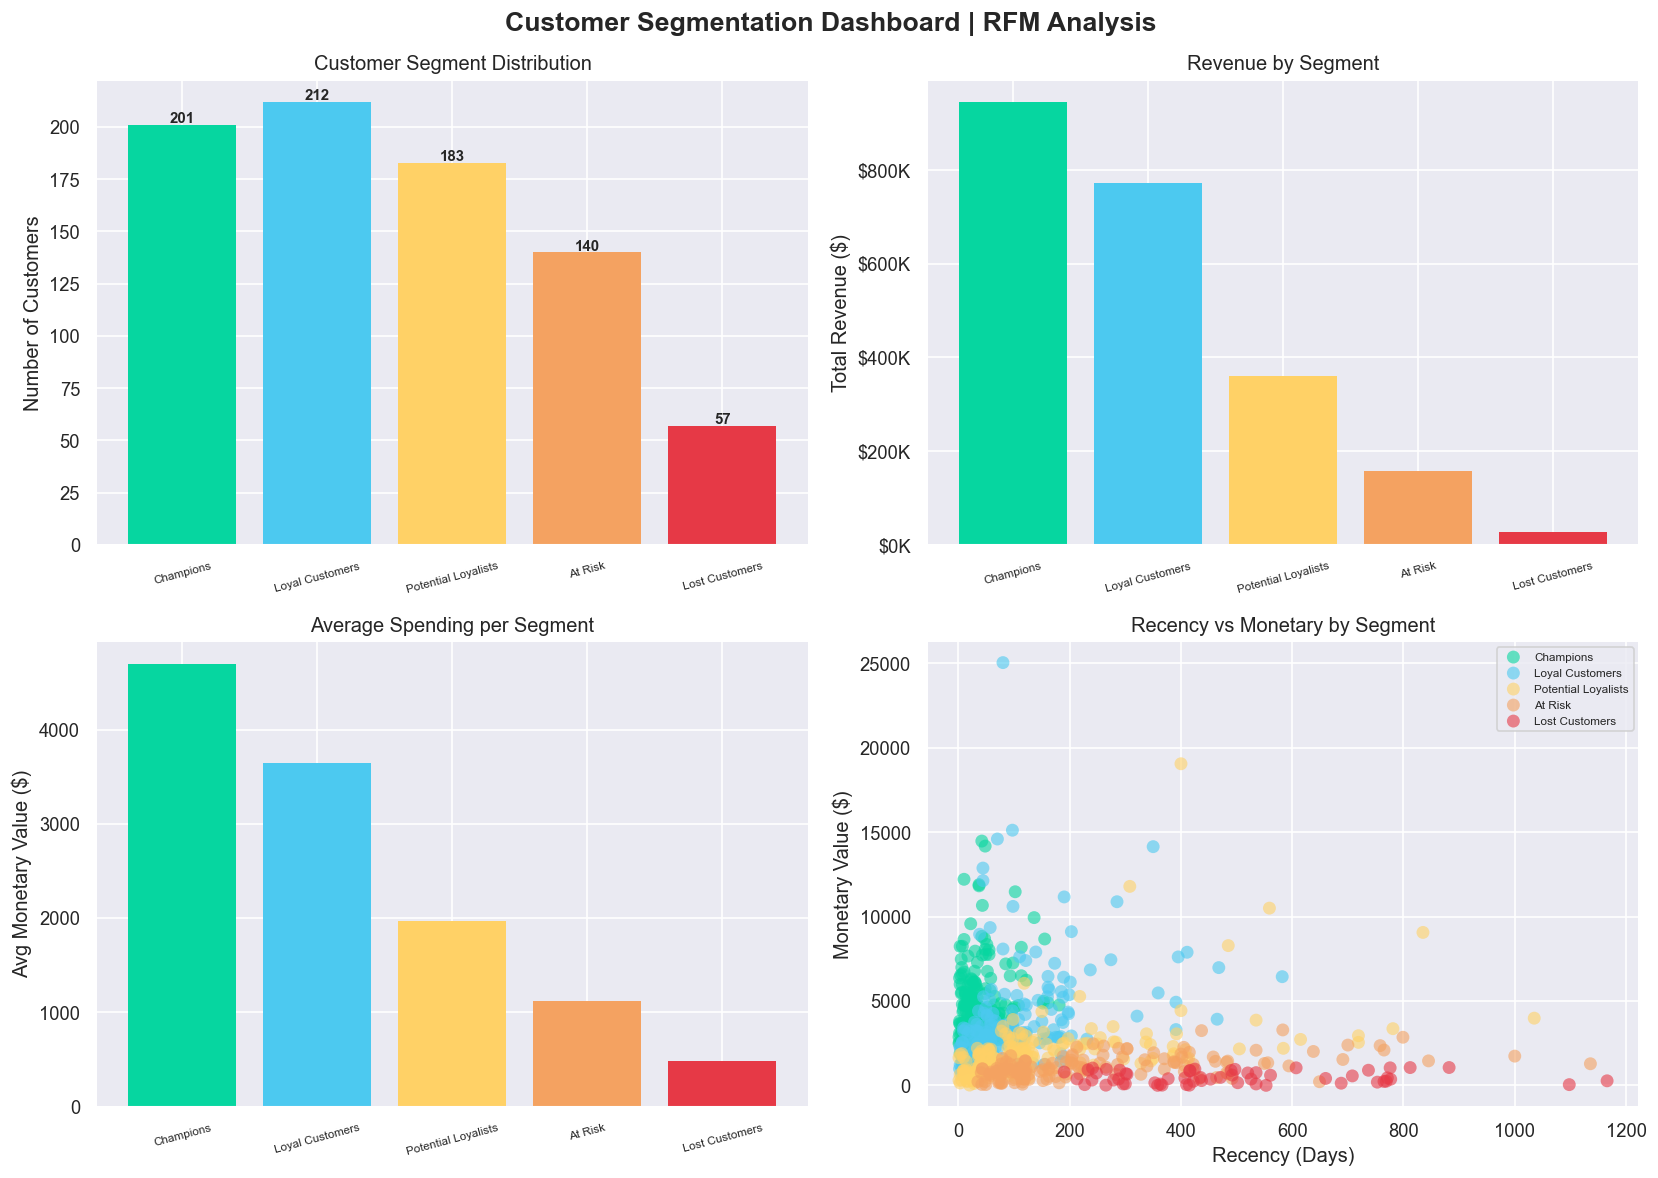

✅ Dashboard saved as customer_segmentation_dashboard.png


In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Customer Segmentation Dashboard | RFM Analysis",
             fontsize=16, fontweight="bold")

# Chart 1 - Segment Distribution
counts = [segment_counts.get(s, 0) for s in segment_order]
colors = [fig_colors[s] for s in segment_order]
bars = axes[0,0].bar(segment_order, counts, color=colors, edgecolor="none")
for bar, count in zip(bars, counts):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 1, str(count),
                   ha="center", fontsize=9, fontweight="bold")
axes[0,0].set_title("Customer Segment Distribution")
axes[0,0].set_ylabel("Number of Customers")
axes[0,0].tick_params(axis="x", labelsize=7, rotation=15)

# Chart 2 - Revenue by Segment
rev_vals = [revenue_by_segment.get(s, 0) for s in segment_order]
axes[0,1].bar(segment_order, rev_vals, color=colors, edgecolor="none")
axes[0,1].set_title("Revenue by Segment")
axes[0,1].set_ylabel("Total Revenue ($)")
axes[0,1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
axes[0,1].tick_params(axis="x", labelsize=7, rotation=15)

# Chart 3 - Avg Monetary per Segment
monetary_vals = [segment_summary.loc[s, "Avg_Monetary"]
                 if s in segment_summary.index else 0
                 for s in segment_order]
axes[1,0].bar(segment_order, monetary_vals, color=colors, edgecolor="none")
axes[1,0].set_title("Average Spending per Segment")
axes[1,0].set_ylabel("Avg Monetary Value ($)")
axes[1,0].tick_params(axis="x", labelsize=7, rotation=15)

# Chart 4 - Scatter Recency vs Monetary
for segment in segment_order:
    subset = rfm[rfm["Segment"] == segment]
    axes[1,1].scatter(subset["Recency"], subset["Monetary"],
                      label=segment, color=fig_colors[segment],
                      alpha=0.6, edgecolors="none", s=60)
axes[1,1].set_title("Recency vs Monetary by Segment")
axes[1,1].set_xlabel("Recency (Days)")
axes[1,1].set_ylabel("Monetary Value ($)")
axes[1,1].legend(fontsize=7)

plt.tight_layout()
plt.savefig("customer_segmentation_dashboard.png", 
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dashboard saved as customer_segmentation_dashboard.png")